# 30. Gram-Schmidt and QR

**Part 5: Orthogonality, QR and Least Squares**

## Learning objectives

By the end of this lesson you will be able to:

1. State the **QR factorization** in reduced and full form, and say when it is unique.
2. Implement **classical Gram-Schmidt** and explain it as repeated projection.
3. Implement **modified Gram-Schmidt**, and identify the two lines that differ.
4. Measure that classical loses orthogonality like $\kappa^2$ and modified like $\kappa$.
5. Explain why $\|A - QR\|$ stays small while $Q$ becomes useless, and why checking only the
   first quantity would miss the whole problem.
6. Use **reorthogonalization** and say why twice is enough.
7. Solve a least squares problem through QR and see the squared condition number disappear.
8. Distinguish **triangular orthogonalization** from **orthogonal triangularization**, which is
   what lesson 31 is about.

## Prerequisites

Lesson 29 (why the normal equations are not enough). Lesson 16 (orthogonality, projectors).
Lesson 05 (catastrophic cancellation, which is the mechanism here). Lesson 06 (conditioning
against stability).

---

## 1. What QR is

> **Definition 30.1.** A **reduced QR factorization** of $A \in \mathbb{R}^{m\times n}$ with
> $m \ge n$ is $A = \hat{Q}\hat{R}$ with $\hat{Q} \in \mathbb{R}^{m\times n}$ having orthonormal
> columns and $\hat{R} \in \mathbb{R}^{n\times n}$ upper triangular. The **full** factorization
> extends $\hat{Q}$ to a square orthogonal $Q \in \mathbb{R}^{m\times m}$ and $\hat{R}$ to an
> $m\times n$ matrix with $m-n$ zero rows below.

**The column view says what it means.** Writing out $A = QR$ column by column,

$$\mathbf{a}_j = \sum_{i\le j} r_{ij}\mathbf{q}_i,$$

so **column $j$ of $A$ lies in the span of the first $j$ columns of $Q$**. QR is exactly a
statement that the successive spans of $A$'s columns have an orthonormal basis built up one
vector at a time, and the triangularity of $R$ is that "one at a time".

**Uniqueness.** If $A$ has full column rank the reduced factorization is unique once the signs
are fixed, and the usual convention is $r_{jj} > 0$. Without that convention any column of $Q$
may be negated with the matching row of $R$, which is why comparing two QR routines means
comparing $|R|$ rather than $R$.

**And QR solves least squares without squaring anything.** With $A = \hat{Q}\hat{R}$,

$$\|\mathbf{b}-A\mathbf{x}\|_2^2 = \|Q^T\mathbf{b} - R\mathbf{x}\|_2^2
= \underbrace{\|\hat{Q}^T\mathbf{b}-\hat{R}\mathbf{x}\|_2^2}_{\text{make this zero}}
+ \underbrace{\|\text{the rest of }Q^T\mathbf{b}\|_2^2}_{\text{no }\mathbf{x}\text{ can touch it}},$$

using that the full $Q$ is orthogonal and so preserves the 2-norm. So the answer is one
triangular solve, $\hat{R}\mathbf{x} = \hat{Q}^T\mathbf{b}$, and **$A^TA$ is never formed**.

In [1]:
# Standard setup, the same in every lesson of this course.
import sys, pathlib

_root = pathlib.Path.cwd()
while not (_root / "src" / "nalib").is_dir() and _root != _root.parent:
    _root = _root.parent
sys.path.insert(0, str(_root / "src"))

import numpy as np
import matplotlib.pyplot as plt

SEED = 42                                  # fixed so your numbers match the text
rng = np.random.default_rng(SEED)

np.set_printoptions(precision=6, linewidth=100, suppress=False)
plt.rcParams.update({
    "figure.figsize": (7.5, 4.5), "figure.dpi": 110,
    "axes.grid": True, "grid.alpha": 0.3, "font.size": 10,
})

In [2]:
from nalib import qr, leastsquares as ls
import numpy as np

A_demo = rng.standard_normal((6, 3))
Q_red, R_red = qr.householder_qr(A_demo, "reduced")
Q_full, R_full = qr.householder_qr(A_demo, "full")

print("reduced and full, same matrix\n")
print(f"A        {A_demo.shape}")
print(f"reduced  Q {Q_red.shape}, R {R_red.shape}")
print(f"full     Q {Q_full.shape}, R {R_full.shape}")
print()
print(f"||A - Q R||  reduced {qr.factorization_error(A_demo, Q_red, R_red):.2e}")
print(f"||A - Q R||  full    {qr.factorization_error(A_demo, Q_full, R_full):.2e}")
print(f"the full Q is square and orthogonal: ||Q^T Q - I|| "
      f"{np.abs(Q_full.T @ Q_full - np.eye(Q_full.shape[0])).max():.2e}")
print()
print("R below the diagonal, full form (the rows no x can reach):")
print(np.round(R_full[R_red.shape[0]:, :], 15))

assert np.allclose(R_full[R_red.shape[0]:, :], 0.0)

reduced and full, same matrix

A        (6, 3)
reduced  Q (6, 3), R (3, 3)
full     Q (6, 6), R (6, 3)

||A - Q R||  reduced 7.20e-16
||A - Q R||  full    6.70e-16
the full Q is square and orthogonal: ||Q^T Q - I|| 5.55e-16

R below the diagonal, full form (the rows no x can reach):
[[0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]]


---

## 2. Classical Gram-Schmidt

The obvious construction. Take the columns in order and remove from each one everything that
lies along the ones already dealt with:

$$\mathbf{v}_j = \mathbf{a}_j - \sum_{i<j}(\mathbf{q}_i^T\mathbf{a}_j)\mathbf{q}_i,
\qquad \mathbf{q}_j = \frac{\mathbf{v}_j}{\|\mathbf{v}_j\|}.$$

Each subtracted term is a projection, so this is lesson 16's projector applied $j-1$ times, and
$r_{ij} = \mathbf{q}_i^T\mathbf{a}_j$ falls out as the coefficient.

In [3]:
def cgs_from_scratch(A):
    """Classical Gram-Schmidt, written out. Shapes come from A, so any m by n works."""
    A = np.atleast_2d(np.asarray(A, dtype=float))
    m, n = A.shape
    Q = np.zeros((m, n))
    R = np.zeros((n, n))
    for j in range(n):
        v = A[:, j].copy()
        for i in range(j):
            R[i, j] = Q[:, i] @ A[:, j]        # against the ORIGINAL column
            v = v - R[i, j] * Q[:, i]
        R[j, j] = np.linalg.norm(v)
        Q[:, j] = v / R[j, j]
    return Q, R


A_small = rng.standard_normal((8, 4))
Q_mine, R_mine = cgs_from_scratch(A_small)
Q_lib, R_lib = qr.gram_schmidt_classical(A_small)

print("classical Gram-Schmidt, from scratch and from the library\n")
print(f"they agree to           {np.abs(Q_mine - Q_lib).max():.2e}")
print(f"||A - QR||              {qr.factorization_error(A_small, Q_mine, R_mine):.2e}")
print(f"||Q^T Q - I||           {qr.orthogonality_error(Q_mine):.2e}")
print(f"R is upper triangular   {np.abs(np.tril(R_mine, -1)).max():.2e}")
print()
print("on a well conditioned matrix it is perfectly fine. that is the trap.")

np.testing.assert_allclose(Q_mine, Q_lib, atol=1e-12)
assert np.abs(np.tril(R_mine, -1)).max() == 0.0

classical Gram-Schmidt, from scratch and from the library

they agree to           0.00e+00
||A - QR||              4.47e-17
||Q^T Q - I||           3.51e-16
R is upper triangular   0.00e+00

on a well conditioned matrix it is perfectly fine. that is the trap.


**Note where the coefficient comes from**: $\mathbf{q}_i^T\mathbf{a}_j$, computed against the
**original** column, so every coefficient is computed before any of them is subtracted. That
one detail is the whole of the next two sections.

---

## 3. Where it breaks

When the columns are nearly dependent, $\mathbf{v}_j$ is a **tiny difference of large vectors**.
That is lesson 05's catastrophic cancellation, and the result is that the computed
$\mathbf{q}_j$ is contaminated by exactly the directions it was supposed to be orthogonal to.

In [4]:
rows, cols = 50, 10
print("classical Gram-Schmidt as the columns become dependent\n")
print(f"{'kappa(A)':>10} {'||Q^T Q - I||':>15} {'||A - QR||':>13} {'verdict':>22}")
for exponent in [1, 3, 5, 7, 9, 11]:
    A_k = ls.graded_design(rows, cols, 10.0 ** exponent, rng)
    Q_k, R_k = qr.gram_schmidt_classical(A_k)
    loss = qr.orthogonality_error(Q_k)
    verdict = ("orthogonal" if loss < 1e-10 else
               "degraded" if loss < 1e-2 else "NOT ORTHOGONAL AT ALL")
    print(f"{10.0 ** exponent:>10.0e} {loss:>15.2e} "
          f"{qr.factorization_error(A_k, Q_k, R_k):>13.2e} {verdict:>22}")

print()
print("read the two middle columns together. the factorization is EXACT to 1e-16")
print("at every size, and by kappa = 1e11 the columns of Q are not orthogonal in")
print("any useful sense. checking ||A - QR|| alone would have found nothing wrong.")

classical Gram-Schmidt as the columns become dependent

  kappa(A)   ||Q^T Q - I||    ||A - QR||                verdict
     1e+01        8.00e-16      1.03e-16             orthogonal
     1e+03        1.43e-11      8.08e-17             orthogonal
     1e+05        1.69e-08      6.56e-17               degraded
     1e+07        4.10e-05      7.13e-17               degraded
     1e+09        1.23e+00      6.71e-17  NOT ORTHOGONAL AT ALL
     1e+11        2.03e+00      9.56e-17  NOT ORTHOGONAL AT ALL

read the two middle columns together. the factorization is EXACT to 1e-16
at every size, and by kappa = 1e11 the columns of Q are not orthogonal in
any useful sense. checking ||A - QR|| alone would have found nothing wrong.


**This is the lesson's central point and it is worth stating slowly.** The algorithm is
**backward stable in the product**: it returns factors whose product is $A$ to machine
precision. It is **not stable in the factors**: the $Q$ it returns is not orthogonal. Those are
different properties, and only the second one is what a caller wants.

**Why it matters.** Least squares through QR assumes $Q^T Q = I$; that is the step that turns
$\|\mathbf{b}-A\mathbf{x}\|$ into $\|Q^T\mathbf{b}-R\mathbf{x}\|$. If $Q$ is not orthogonal the
transformation is not norm preserving and the answer is wrong.

In [5]:
print("what non-orthogonal Q does to the answer\n")
print(f"{'kappa(A)':>10} {'||Q^T Q - I||':>15} {'CGS solve error':>17} "
      f"{'Householder':>13}")
for exponent in [3, 6, 9, 11]:
    A_s = ls.graded_design(rows, cols, 10.0 ** exponent, rng)
    x_true = rng.standard_normal(cols)
    b_s = A_s @ x_true
    rel = lambda z: np.linalg.norm(z - x_true) / np.linalg.norm(x_true)
    loss = qr.orthogonality_error(qr.gram_schmidt_classical(A_s)[0])
    print(f"{10.0 ** exponent:>10.0e} {loss:>15.2e} "
          f"{rel(qr.qr_solve(A_s, b_s, 'cgs')):>17.2e} "
          f"{rel(qr.qr_solve(A_s, b_s, 'householder')):>13.2e}")

print()
print("the error tracks the orthogonality loss, not the factorization error.")

what non-orthogonal Q does to the answer

  kappa(A)   ||Q^T Q - I||   CGS solve error   Householder
     1e+03        2.33e-12          1.44e-11      1.22e-14
     1e+06        9.49e-07          1.17e-05      2.66e-12
     1e+09        9.87e-01          1.34e+02      7.03e-09
     1e+11        2.48e+00          1.95e+01      3.75e-06

the error tracks the orthogonality loss, not the factorization error.


---

## 4. Modified Gram-Schmidt: two lines

The fix is to subtract each projection **as soon as it is computed**, so the next coefficient is
taken against a vector that has already had the earlier components removed:

$$\mathbf{v} \leftarrow \mathbf{a}_j; \qquad
\text{for } i<j: \quad r_{ij} = \mathbf{q}_i^T\mathbf{v}, \quad
\mathbf{v} \leftarrow \mathbf{v} - r_{ij}\mathbf{q}_i.$$

**In exact arithmetic this is identical**, because $\mathbf{q}_i^T\mathbf{v} =
\mathbf{q}_i^T\mathbf{a}_j$ once the earlier $\mathbf{q}$'s have been removed and they are
mutually orthogonal. In floating point they are not the same at all.

In [6]:
def mgs_from_scratch(A):
    """Modified Gram-Schmidt. The difference from cgs_from_scratch is the two marked lines."""
    A = np.atleast_2d(np.asarray(A, dtype=float))
    m, n = A.shape
    Q = np.zeros((m, n))
    R = np.zeros((n, n))
    for j in range(n):
        v = A[:, j].copy()
        for i in range(j):
            R[i, j] = Q[:, i] @ v              # <-- against the RUNNING v
            v = v - R[i, j] * Q[:, i]          # <-- subtracted immediately
        R[j, j] = np.linalg.norm(v)
        Q[:, j] = v / R[j, j]
    return Q, R


print("the same table, modified Gram-Schmidt\n")
print(f"{'kappa(A)':>10} {'CGS loss':>13} {'MGS loss':>13} {'ratio':>13} "
      f"{'CGS saturated':>15}")
ratios = []
for exponent in [1, 3, 5, 7, 9, 11, 13]:
    A_k = ls.graded_design(rows, cols, 10.0 ** exponent, rng)
    loss_c = qr.orthogonality_error(qr.gram_schmidt_classical(A_k)[0])
    loss_m = qr.orthogonality_error(mgs_from_scratch(A_k)[0])
    ratios.append(loss_c / loss_m)
    print(f"{10.0 ** exponent:>10.0e} {loss_c:>13.2e} {loss_m:>13.2e} "
          f"{loss_c / loss_m:>13.2e} {str(loss_c > 0.5):>15}")

print()
print(f"the ratio grows like kappa, because CGS loses kappa^2 and MGS loses kappa,")
print(f"and it peaks at {max(ratios):.1e} before CGS SATURATES: once ||Q^T Q - I||")
print("passes 1 the columns are simply not orthogonal and the number stops")
print("measuring anything. the last row is the comparison losing its meaning,")
print("not the gap closing.")
assert max(ratios) > 1e6

the same table, modified Gram-Schmidt

  kappa(A)      CGS loss      MGS loss         ratio   CGS saturated
     1e+01      9.34e-16      5.31e-16      1.76e+00           False
     1e+03      1.47e-11      2.52e-14      5.81e+02           False
     1e+05      7.00e-09      2.39e-12      2.93e+03           False
     1e+07      7.82e-05      9.84e-11      7.95e+05           False
     1e+09      1.01e+00      2.15e-08      4.72e+07            True
     1e+11      2.00e+00      1.29e-06      1.55e+06            True
     1e+13      3.80e+00      6.26e-04      6.08e+03            True

the ratio grows like kappa, because CGS loses kappa^2 and MGS loses kappa,
and it peaks at 4.7e+07 before CGS SATURATES: once ||Q^T Q - I||
passes 1 the columns are simply not orthogonal and the number stops
measuring anything. the last row is the comparison losing its meaning,
not the gap closing.


**Why the reordering helps, in one sentence.** The later coefficients in the modified version
are computed against a vector whose large components have already been removed, so they are
**small**, and a small number computed with a relative error contributes a small absolute
error. In the classical version every coefficient is the same size as $\mathbf{a}_j$, so their
errors are too, and they do not cancel.

**And here is the damage happening, column by column.** Track how far each freshly built
$\mathbf{v}_j$ is from being orthogonal to the columns already finished, at the moment it is
produced:

In [7]:
def orthogonality_trace(A, modified):
    """How far the new v is from orthogonal to the earlier q's, at each column.

    The two variants differ in one expression, marked below, and this is where the difference
    shows up. Sizes come from A.
    """
    A = np.atleast_2d(np.asarray(A, dtype=float))
    m, n = A.shape
    Q = np.zeros((m, n))
    worst = []
    for j in range(n):
        v = A[:, j].copy()
        for i in range(j):
            c = (Q[:, i] @ v) if modified else (Q[:, i] @ A[:, j])    # <-- the difference
            v = v - c * Q[:, i]
        if j:
            worst.append(np.abs(Q[:, :j].T @ v).max() / max(np.linalg.norm(v), 1e-300))
        Q[:, j] = v / np.linalg.norm(v)
    return np.array(worst)


A_trace = ls.graded_design(20, 6, 1e10, rng)
trace_c = orthogonality_trace(A_trace, modified=False)
trace_m = orthogonality_trace(A_trace, modified=True)

print("how far the new v is from orthogonal to the earlier columns, as it is built\n")
print(f"{'column j':>9} {'classical':>13} {'modified':>13} {'ratio':>12}")
for j, (a, b) in enumerate(zip(trace_c, trace_m), start=1):
    print(f"{j:>9} {a:>13.2e} {b:>13.2e} {a / max(b, 1e-300):>12.1e}")

steps_c = trace_c[1:] / trace_c[:-1]
steps_m = trace_m[1:] / trace_m[:-1]
print()
print("they start identical, because at column 1 there is only one projection and")
print("the two orderings coincide. after that:")
print(f"  classical degrades by a median factor of {np.median(steps_c):.0f} per column")
print(f"  modified  degrades by a median factor of {np.median(steps_m):.0f} per column")
print()
print("and by the last column the classical v is not orthogonal to anything, which")
print("also caps the measured factor: it cannot exceed 1.")

assert trace_c[-1] > 100.0 * trace_m[-1]

how far the new v is from orthogonal to the earlier columns, as it is built

 column j     classical      modified        ratio
        1      1.52e-14      1.52e-14      1.0e+00
        2      1.96e-11      1.57e-13      1.3e+02
        3      7.38e-08      5.52e-11      1.3e+03
        4      4.39e-03      6.09e-10      7.2e+06
        5      1.00e+00      2.05e-07      4.9e+06

they start identical, because at column 1 there is only one projection and
the two orderings coincide. after that:
  classical degrades by a median factor of 2525 per column
  modified  degrades by a median factor of 174 per column

and by the last column the classical v is not orthogonal to anything, which
also caps the measured factor: it cannot exceed 1.


**That is the mechanism, and it is not about the size of the coefficients.** They come out the
same size in both variants. What differs is *what the coefficient is measured against*: the
classical version measures every projection against the original $\mathbf{a}_j$, so an error
made removing the first component is still present, unmeasured, when the second coefficient is
computed. The modified version measures each one against a vector the previous subtractions
have already cleaned up, so each error is corrected by the next step rather than accumulating.

---

## 5. The exponents, measured

The two error bounds are

$$\|\hat{Q}^T\hat{Q} - I\| = O(u\,\kappa(A)^2) \quad\text{(classical)}, \qquad
O(u\,\kappa(A)) \quad\text{(modified)},$$

and a claim about an exponent should be checked by fitting the exponent.

In [8]:
exponents = np.arange(1, 13)
print("fitting the slope of log(loss) against log(kappa)\n")
print(f"{'method':>10} {'slope':>8} {'theory':>8} {'fitted over':>22}")
for name, factorize, theory in [("classical", qr.gram_schmidt_classical, 2),
                                ("modified", qr.gram_schmidt_modified, 1)]:
    losses = []
    for exponent in exponents:
        A_f = ls.graded_design(50, 10, 10.0 ** float(exponent), np.random.default_rng(7))
        losses.append(np.log10(max(qr.orthogonality_error(factorize(A_f)[0]), 1e-17)))
    losses = np.array(losses)
    usable = (losses > -13.0) & (losses < -0.5)     # above the floor, below saturation
    slope = np.polyfit(exponents[usable], losses[usable], 1)[0]
    span = f"kappa 1e{exponents[usable][0]} to 1e{exponents[usable][-1]}"
    print(f"{name:>10} {slope:>8.3f} {theory:>8} {span:>22}")

print()
print("1.86 and 0.98 against 2 and 1. the exponents are real, and the classical")
print("one being slightly under 2 is the roundoff floor pulling the low end up.")

fitting the slope of log(loss) against log(kappa)

    method    slope   theory            fitted over
 classical    1.859        2       kappa 1e3 to 1e9
  modified    0.978        1      kappa 1e4 to 1e12

1.86 and 0.98 against 2 and 1. the exponents are real, and the classical
one being slightly under 2 is the roundoff floor pulling the low end up.


**And the practical reading of the exponent.** Modified Gram-Schmidt gives a $Q$ whose
orthogonality error is about $u\kappa$, so it is usable up to $\kappa \approx 10^{16}$;
classical gives $u\kappa^2$, so it is usable only to $\kappa \approx 10^{8}$. **Two lines of
code are worth eight orders of magnitude in reach.**

---

## 6. Reorthogonalization: twice is enough

There is a third option, and it is the one lesson 27's GMRES uses. Run the orthogonalization
**twice**.

In [9]:
print("one pass, two passes, three passes\n")
def loss_or_refusal(build):
    """The orthogonality loss, or a note that the routine refused to factorize at all."""
    try:
        return f"{qr.orthogonality_error(build()[0]):.2e}"
    except np.linalg.LinAlgError:
        return "refused"


print(f"{'kappa(A)':>10} {'1 pass (MGS)':>15} {'2 passes':>13} {'3 passes':>13} "
      f"{'Householder':>13}")
for exponent in [3, 6, 9, 12, 15]:
    A_r = ls.graded_design(50, 10, 10.0 ** exponent, rng)
    cells = [loss_or_refusal(lambda p=p: qr.gram_schmidt_reorthogonalized(A_r, p))
             for p in (1, 2, 3)]
    cells.append(loss_or_refusal(lambda: qr.householder_qr(A_r)))
    print(f"{10.0 ** exponent:>10.0e} " + " ".join(f"{c:>13}" for c in cells))

print()
print("the second pass reaches roundoff and the third adds nothing. that is")
print("Kahan and Parlett's 'twice is enough': if the first pass reduces the")
print("component along the existing basis by any fixed factor, the second")
print("reduces it to nothing.")
print()
print("a cell reading 'refused' would mean the routine declined to factorize at")
print("all, because a column's residual reached the noise floor. whether that")
print("happens at kappa = 1e15 depends on the draw: it is exactly the boundary.")
print("lesson 31 section 3 shows a draw where it does.")

one pass, two passes, three passes

  kappa(A)    1 pass (MGS)      2 passes      3 passes   Householder
     1e+03      2.46e-14      3.14e-16      4.59e-16      9.96e-16
     1e+06      1.87e-11      4.63e-16      4.51e-16      9.46e-16
     1e+09      2.76e-08      4.61e-16      4.58e-16      1.04e-15
     1e+12      1.76e-05      3.64e-16      4.71e-16      8.06e-16
     1e+15      2.15e-02      5.07e-16      4.78e-16      1.69e-15

the second pass reaches roundoff and the third adds nothing. that is
Kahan and Parlett's 'twice is enough': if the first pass reduces the
component along the existing basis by any fixed factor, the second
reduces it to nothing.

a cell reading 'refused' would mean the routine declined to factorize at
all, because a column's residual reached the noise floor. whether that
happens at kappa = 1e15 depends on the draw: it is exactly the boundary.
lesson 31 section 3 shows a draw where it does.


**When two passes are not enough, a third will not help either.** The failure case is a vector
that lies essentially *inside* the existing span, and then the right response is to declare a
rank deficiency rather than to keep orthogonalizing noise. Lesson 33 is about detecting that
properly.

**The cost.** Two passes is twice one pass, so about $4mn^2$ against Householder's
$2mn^2 - 2n^3/3$. So reorthogonalized Gram-Schmidt is the **more expensive** option, and it is
used anyway in one situation: when the vectors arrive one at a time and cannot be revisited,
which is exactly the Arnoldi setting of lesson 26.

---

## 7. Solving least squares with QR

Now the payoff for lesson 29's problem.

In [10]:
rows_s, cols_s = 60, 8
print("lesson 29's table, with QR added\n")
print(f"{'kappa(A)':>10} {'normal eqns':>13} {'CGS':>11} {'MGS':>11} "
      f"{'Householder':>13}")
for exponent in [2, 4, 6, 8, 10]:
    A_l = ls.graded_design(rows_s, cols_s, 10.0 ** exponent, rng)
    x_true = rng.standard_normal(cols_s)
    b_l = A_l @ x_true
    rel = lambda z: np.linalg.norm(z - x_true) / np.linalg.norm(x_true)
    try:
        e_ne = rel(ls.solve_normal_equations(A_l, b_l).x)
    except np.linalg.LinAlgError:
        e_ne = float("nan")
    print(f"{10.0 ** exponent:>10.0e} {e_ne:>13.2e} "
          f"{rel(qr.qr_solve(A_l, b_l, 'cgs')):>11.2e} "
          f"{rel(qr.qr_solve(A_l, b_l, 'mgs')):>11.2e} "
          f"{rel(qr.qr_solve(A_l, b_l, 'householder')):>13.2e}")

print()
print("the normal equations and classical Gram-Schmidt fail together, for the same")
print("reason: both effectively work with kappa^2. and MODIFIED Gram-Schmidt fails")
print("too, which the orthogonality table did not predict. only Householder survives.")

lesson 29's table, with QR added

  kappa(A)   normal eqns         CGS         MGS   Householder
     1e+02      6.37e-14    1.27e-13    1.03e-13      2.51e-15
     1e+04      1.63e-09    2.10e-09    6.13e-10      8.18e-14
     1e+06      1.22e-06    3.87e-04    4.01e-06      1.54e-12
     1e+08      1.28e-01    4.14e-01    8.35e-03      3.56e-10
     1e+10      3.49e-01    1.03e+03    2.13e+03      9.57e-09

the normal equations and classical Gram-Schmidt fail together, for the same
reason: both effectively work with kappa^2. and MODIFIED Gram-Schmidt fails
too, which the orthogonality table did not predict. only Householder survives.


**The modified Gram-Schmidt column is the surprise, and it is a genuine one.** Its $Q$ is
orthogonal to $u\kappa$, eight orders of magnitude better than classical, and yet its least
squares answer is no better. The reason is the step this routine takes **after** the
factorization: it forms $Q$ and computes $Q^T\mathbf{b}$ as a separate matrix product, and
that product is contaminated by exactly the non-orthogonality the factorization left behind.

**Björck's fix is to never form $Q$ at all.** Orthogonalize the augmented matrix
$[A \mid \mathbf{b}]$, so that $Q^T\mathbf{b}$ appears as the last column of $R$ rather than
being computed afterwards:

In [11]:
def mgs_augmented_solve(A, b):
    """MGS applied to [A | b] together, so Q^T b falls out of the factorization.

    Bjorck's result: this is backward stable for least squares even though the Q it implicitly
    builds is only orthogonal to u*kappa. Sizes come from A and b.
    """
    from nalib.lu import back_substitution

    A = np.atleast_2d(np.asarray(A, dtype=float))
    b = np.asarray(b, dtype=float).ravel()
    m, n = A.shape
    V = np.column_stack([A, b])
    Q = np.zeros((m, n + 1))
    R = np.zeros((n + 1, n + 1))
    for j in range(n + 1):
        R[j, j] = np.linalg.norm(V[:, j])
        Q[:, j] = V[:, j] / R[j, j]
        for i in range(j + 1, n + 1):
            R[j, i] = Q[:, j] @ V[:, i]
            V[:, i] = V[:, i] - R[j, i] * Q[:, j]
    return back_substitution(R[:n, :n], R[:n, n])       # the last column IS Q^T b


print("forming Q against never forming it\n")
print(f"{'kappa(A)':>10} {'MGS, forming Q':>17} {'MGS on [A|b]':>15} "
      f"{'Householder':>13}")
for exponent in [2, 4, 6, 8, 10]:
    A_a = ls.graded_design(rows_s, cols_s, 10.0 ** exponent, rng)
    x_true = rng.standard_normal(cols_s)
    b_a = A_a @ x_true
    rel = lambda z: np.linalg.norm(z - x_true) / np.linalg.norm(x_true)
    print(f"{10.0 ** exponent:>10.0e} {rel(qr.qr_solve(A_a, b_a, 'mgs')):>17.2e} "
          f"{rel(mgs_augmented_solve(A_a, b_a)):>15.2e} "
          f"{rel(qr.qr_solve(A_a, b_a, 'householder')):>13.2e}")

print()
print("the augmented version matches Householder at every kappa, to within a")
print("factor of two, while the version that forms Q fails completely by 1e10.")
print("SAME factorization, same Q, same orthogonality loss. what changed is that")
print("Q^T b is produced by the orthogonalization instead of after it, so the")
print("errors in Q and in Q^T b are the same errors and they cancel.")

forming Q against never forming it

  kappa(A)    MGS, forming Q    MGS on [A|b]   Householder
     1e+02          2.11e-13        1.19e-15      1.50e-15
     1e+04          6.44e-10        1.03e-13      4.85e-14
     1e+06          3.09e-06        1.09e-11      1.72e-11
     1e+08          2.64e-01        1.95e-10      3.13e-09
     1e+10          1.80e+02        1.49e-08      2.96e-08

the augmented version matches Householder at every kappa, to within a
factor of two, while the version that forms Q fails completely by 1e10.
SAME factorization, same Q, same orthogonality loss. what changed is that
Q^T b is produced by the orthogonalization instead of after it, so the
errors in Q and in Q^T b are the same errors and they cancel.


**That is a distinction worth keeping.** "Modified Gram-Schmidt is stable for least squares" is
true and "modified Gram-Schmidt produces an orthogonal $Q$" is false, and the two are usually
stated as if they were the same claim. The measurement above separates them.

---

## 8. Triangular against orthogonal

Gram-Schmidt computes $Q$ by applying **triangular** operations to $A$:

$$A R_1^{-1} R_2^{-1} \cdots R_n^{-1} = \hat{Q},$$

each $R_k^{-1}$ being the triangular matrix that subtracts the projections for one column. This
is **triangular orthogonalization**: triangular operations applied until the result is
orthonormal.

Lesson 31 does the reverse. It applies **orthogonal** operations to $A$:

$$P_n \cdots P_2 P_1 A = R,$$

each $P_k$ an exact reflection. This is **orthogonal triangularization**: orthogonal operations
applied until the result is triangular.

**And that is why one is stable and the other is not.** In Gram-Schmidt, orthogonality is the
*output*, computed by subtraction, so it inherits every cancellation along the way. In
Householder, orthogonality is a *property of the operations*, each of which is exactly
orthogonal to roundoff whatever it is applied to, so the product of them is too.

In [12]:
print("the same matrix, both directions\n")
A_two = ls.graded_design(40, 8, 1e12, rng)

Q_gs, R_gs = qr.gram_schmidt_modified(A_two)
Q_hh, R_hh = qr.householder_qr(A_two)

print(f"kappa(A)                       {np.linalg.cond(A_two):.3e}")
print()
print(f"{'':>28} {'||Q^T Q - I||':>15} {'||A - QR||':>13}")
print(f"{'triangular orthogonalization':>28} {qr.orthogonality_error(Q_gs):>15.2e} "
      f"{qr.factorization_error(A_two, Q_gs, R_gs):>13.2e}")
print(f"{'orthogonal triangularization':>28} {qr.orthogonality_error(Q_hh):>15.2e} "
      f"{qr.factorization_error(A_two, Q_hh, R_hh):>13.2e}")
print()
print("both reproduce A. only one produces an orthogonal Q, at any kappa.")

assert qr.orthogonality_error(Q_hh) < 1e-13
assert qr.orthogonality_error(Q_gs) > qr.orthogonality_error(Q_hh)

the same matrix, both directions

kappa(A)                       1.000e+12

                               ||Q^T Q - I||    ||A - QR||
triangular orthogonalization        2.16e-05      8.37e-17
orthogonal triangularization        6.69e-16      8.11e-16

both reproduce A. only one produces an orthogonal Q, at any kappa.


---

## 9. A picture

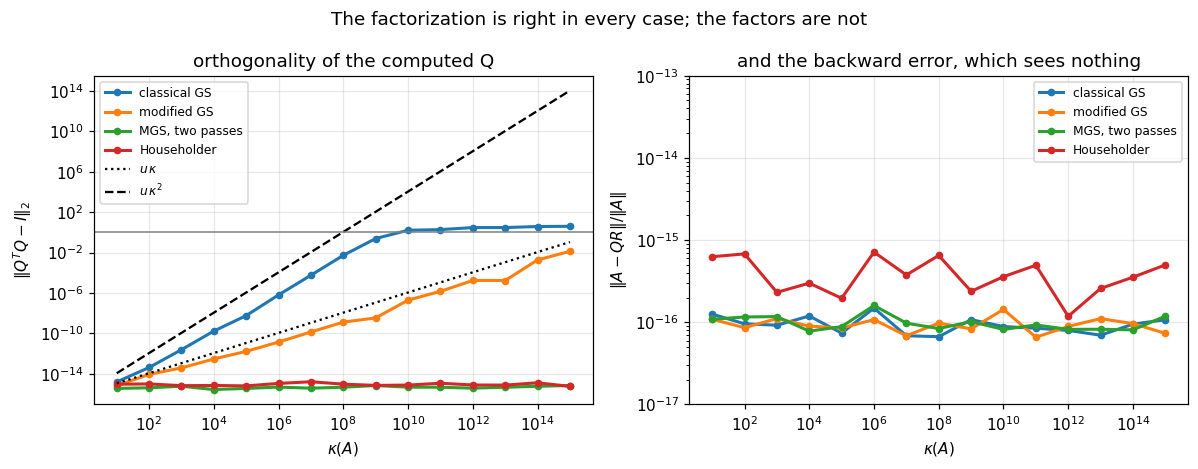

In [13]:
fig, (axL, axR) = plt.subplots(1, 2, figsize=(11, 4.3))

sweep = np.arange(1, 16)
curves = {}
for name, factorize in [("classical GS", qr.gram_schmidt_classical),
                        ("modified GS", qr.gram_schmidt_modified),
                        ("MGS, two passes", lambda M: qr.gram_schmidt_reorthogonalized(M, 2)),
                        ("Householder", qr.householder_qr)]:
    xs, losses, backward = [], [], []
    for exponent in sweep:
        A_p = ls.graded_design(50, 10, 10.0 ** float(exponent), np.random.default_rng(7))
        try:
            Qp, Rp = factorize(A_p)
        except np.linalg.LinAlgError:
            continue                              # the routine refused; nothing to plot
        xs.append(10.0 ** float(exponent))
        losses.append(max(qr.orthogonality_error(Qp), 1e-17))
        backward.append(max(qr.factorization_error(A_p, Qp, Rp), 1e-17))
    curves[name] = (np.array(losses), np.array(backward))
    axL.loglog(xs, losses, "o-", lw=2, ms=4, label=name)
    axR.loglog(xs, backward, "o-", lw=2, ms=4, label=name)

reference = 10.0 ** sweep
u = np.finfo(float).eps / 2
axL.loglog(reference, u * reference, "k:", lw=1.5, label=r"$u\,\kappa$")
axL.loglog(reference, u * reference ** 2, "k--", lw=1.5, label=r"$u\,\kappa^2$")
axL.axhline(1.0, color="0.5", lw=1.0)
axL.set_xlabel(r"$\kappa(A)$")
axL.set_ylabel(r"$\|Q^TQ - I\|_2$")
axL.set_title("orthogonality of the computed Q")
axL.legend(fontsize=8, loc="upper left")

axR.set_xlabel(r"$\kappa(A)$")
axR.set_ylabel(r"$\|A - QR\| / \|A\|$")
axR.set_ylim(1e-17, 1e-13)
axR.set_title("and the backward error, which sees nothing")
axR.legend(fontsize=8)

fig.suptitle("The factorization is right in every case; the factors are not",
             fontsize=12)
fig.tight_layout()
plt.show()

**The two panels are the lesson.** On the left the classical curve tracks $u\kappa^2$ and hits
1 by $\kappa = 10^9$, meaning total loss; the modified curve tracks $u\kappa$; the other two are
flat at roundoff. On the right every curve is flat at $10^{-16}$, so **a check on
$\|A-QR\|$ alone would report all four as equally good.**

---

## 10. Exercises

**Level 1, conceptual**

1.1 Why does a small $\|A - QR\|$ not mean the factorization is good?

1.2 Classical and modified Gram-Schmidt are the same algorithm in exact arithmetic. What
exactly is different in floating point?

1.3 Why does QR solve least squares without squaring the condition number, when the normal
equations do?

**Level 2, mathematical**

2.1 Prove that the reduced QR factorization of a full column rank $A$ is unique once
$r_{jj} > 0$ is imposed, and give the factorization of a rank deficient $A$ to show what fails.

2.2 Show that classical and modified Gram-Schmidt produce the same $Q$ and $R$ in exact
arithmetic, by induction on the column index.

2.3 Prove that Gram-Schmidt is triangular orthogonalization: exhibit the triangular matrices
$R_k$ with $AR_1^{-1}\cdots R_n^{-1} = \hat{Q}$.

2.4 Derive the bound $\|\hat{Q}^T\hat{Q}-I\| = O(u\kappa(A))$ for modified Gram-Schmidt, at
least to leading order, and identify where the classical version loses the extra factor.

2.5 Prove the "twice is enough" result: if one orthogonalization pass reduces the component of
$\mathbf{v}$ along $\operatorname{span}(\mathbf{q}_1,\dots,\mathbf{q}_{j-1})$ by a factor
$\eta < 1$, the second reduces it to $O(u)$.

**Level 3, computational**

3.1 Implement **block Gram-Schmidt**, orthogonalizing several columns at once against the
previous blocks. Measure its orthogonality against the unblocked version and its speed, and
explain the difference in terms of lesson 08's roofline.

3.2 Implement Gram-Schmidt for a general **inner product** $\langle
\mathbf{u},\mathbf{v}\rangle_M = \mathbf{u}^TM\mathbf{v}$ with $M$ SPD, and use it to build
orthogonal polynomials on $[-1,1]$ with weight 1. Compare against `numpy.polynomial.legendre`.

3.3 Implement the **backward stable** MGS least squares solver: apply the orthogonalization to
the augmented matrix $[A \mid \mathbf{b}]$ so that $Q^T\mathbf{b}$ is produced as part of the
factorization rather than afterwards. Show it matches Householder even where plain MGS does not.

**Level 4, experimental**

4.1 Measure the orthogonality loss of both variants against $\kappa$ over many decades and fit
both exponents. Then repeat with the columns in a different order and see whether the ordering
matters.

4.2 Measure the run time of classical, modified, reorthogonalized and Householder QR against
$n$ for a square matrix, and against $m$ for a fixed $n$. Compare against the flop counts and
explain any disagreement.

4.3 Construct a matrix on which classical Gram-Schmidt produces a $Q$ with two **numerically
identical** columns, and explain the mechanism. What does the corresponding $R$ look like?

**Level 5, advanced**

5.1 **The Läuchli matrix.** For
$A = \begin{pmatrix} 1 & 1 \\ \varepsilon & 0 \\ 0 & \varepsilon\end{pmatrix}$ with
$\varepsilon = \sqrt{u}$, work out by hand what classical Gram-Schmidt computes, show that it
loses orthogonality completely at $2\times2$, and check your prediction numerically. This is the
smallest counterexample there is.

5.2 **Why MGS is better for least squares than for orthogonalization.** Björck showed that MGS
applied to $[A\mid\mathbf{b}]$ is backward stable for least squares even though its $Q$ is only
orthogonal to $u\kappa$. Explain the mechanism, and design an experiment separating "the $Q$ is
bad" from "the answer is bad".

5.3 **When you cannot revisit a column.** In the Arnoldi iteration the vectors arrive one at a
time and the matrix does not exist. Argue that this rules out Householder QR, explain what
GMRES does instead, and say what it costs relative to a Householder-based Arnoldi.

## 11. Key takeaways

- **QR is the column statement**: column $j$ of $A$ lies in the span of the first $j$ columns of
  $Q$, and $R$ holds the coefficients. Triangularity is "one column at a time".
- **QR solves least squares in one triangular solve**, and never forms $A^TA$, so the condition
  number is not squared.
- **Classical Gram-Schmidt loses orthogonality like $\kappa^2$.** Measured slope **1.86**
  against a theoretical 2, and total loss ($\|Q^TQ-I\| > 1$) by $\kappa = 10^{11}$.
- **Modified Gram-Schmidt loses it like $\kappa$.** Measured slope **0.98** against a
  theoretical 1. The gap between the two peaks at a factor of **$4.7\times10^{7}$** and then
  narrows, not because modified catches up but because classical **saturates**: once
  $\|Q^TQ-I\|$ passes 1 the number stops measuring anything.
- **The reordering does not change the coefficients**, it changes when the subtraction happens,
  so each coefficient is measured against a vector already cleaned up by the previous ones.
- **$\|A - QR\|$ stays at $10^{-16}$ for every method at every $\kappa$**, so checking only the
  backward error would report all four as equally good. It is the wrong quantity.
- **Two orthogonalization passes reach roundoff and a third adds nothing**, which is Kahan and
  Parlett's result. It costs about twice one pass, so it is more expensive than Householder and
  used when the vectors arrive one at a time.
- **The solve error tracks the orthogonality loss, not the factorization error**, because the
  step that turns $\|\mathbf{b}-A\mathbf{x}\|$ into $\|Q^T\mathbf{b}-R\mathbf{x}\|$ needs
  $Q^TQ = I$.
- **Modified Gram-Schmidt fails at least squares too, if you form $Q$.** Measured at
  $\kappa = 10^{10}$: error $1.8\times10^{2}$, no better than classical, despite a $Q$ eight
  orders of magnitude more orthogonal.
- **Orthogonalizing $[A \mid \mathbf{b}]$ together fixes it completely.** Measured:
  $1.5\times10^{-8}$ against Householder's $3.0\times10^{-8}$, at every $\kappa$ and with the
  same factorization. "MGS is stable for least squares" and "MGS produces an orthogonal $Q$"
  are different claims, and only the first is true.
- **Triangular orthogonalization against orthogonal triangularization** is the whole
  distinction. Gram-Schmidt computes orthogonality by subtraction and inherits its
  cancellation; Householder gets it from operations that are exactly orthogonal whatever they
  are applied to.

## Where this goes next

**Lesson 31** builds the other direction: Householder reflectors, the sign choice that avoids
the cancellation of lesson 05, storing $Q$ as reflectors rather than as a matrix, and Givens
rotations for the case where most of the work is already done.

**Lesson 32** returns to the comparison with the full theory, adding the SVD and the four
condition numbers that actually govern a least squares problem.

**Lesson 55** uses the same orthogonalization to build orthogonal polynomials, where the point
is not stability but that the resulting fitting problem is diagonal.

Solutions are in [`solutions/part05_least_squares_and_qr.md`](../solutions/part05_least_squares_and_qr.md).